I'll start with Colab 1: L1/L2 Regularization by implementing a simple neural network using Keras with L1 (Lasso) and L2 (Ridge) regularization. The Colab will:

✅ Load and preprocess a dataset (MNIST or CIFAR-10).
✅ Implement L1 and L2 regularization in a fully connected neural network.
✅ Compare the performance of models with and without regularization (A/B testing).
✅ Visualize training loss and accuracy.

I'll generate the first Colab notebook now. Stay tuned! 🚀

L1 L2 Regularization

Answer in chat instead
This Colab demonstrates L1/L2 regularization in a CNN trained on CIFAR-10. It compares models with no regularization, L1, L2, and combined L1/L2 and plots validation accuracy. 🚀

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load dataset (CIFAR-10 for diversity)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [ ]:
# Normalize images to [0,1] range
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
# Define a simple CNN model with L1/L2 regularization
def create_model(regularizer=None):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizer, input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizer),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizer),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
# Compile models with different regularizations
models = {
    "No Regularization": create_model(),
    "L1 Regularization": create_model(regularizers.l1(0.01)),
    "L2 Regularization": create_model(regularizers.l2(0.01)),
    "L1_L2 Regularization": create_model(regularizers.l1_l2(l1=0.01, l2=0.01))
}

histories = {}

for name, model in models.items():
    print(f"Training model: {name}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=64, verbose=1)
    histories[name] = history

Training model: No Regularization
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 80ms/step - accuracy: 0.3542 - loss: 1.7658 - val_accuracy: 0.5583 - val_loss: 1.2502
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.5759 - loss: 1.2021 - val_accuracy: 0.6125 - val_loss: 1.1167
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.6321 - loss: 1.0526 - val_accuracy: 0.6430 - val_loss: 1.0361
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 81ms/step - accuracy: 0.6629 - loss: 0.9658 - val_accuracy: 0.6598 - val_loss: 0.9954
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 81ms/step - accuracy: 0.6853 - loss: 0.9135 - val_accuracy: 0.6703 - val_loss: 0.9594
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 81ms/step - accuracy: 0.7060 - loss: 0.8522 - val_accuracy: 0.6828 - val_loss: 0.9284
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.7221 - loss: 0.8043 - val_accuracy: 0.6847 - val_loss: 0.9201
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 79ms/step - 

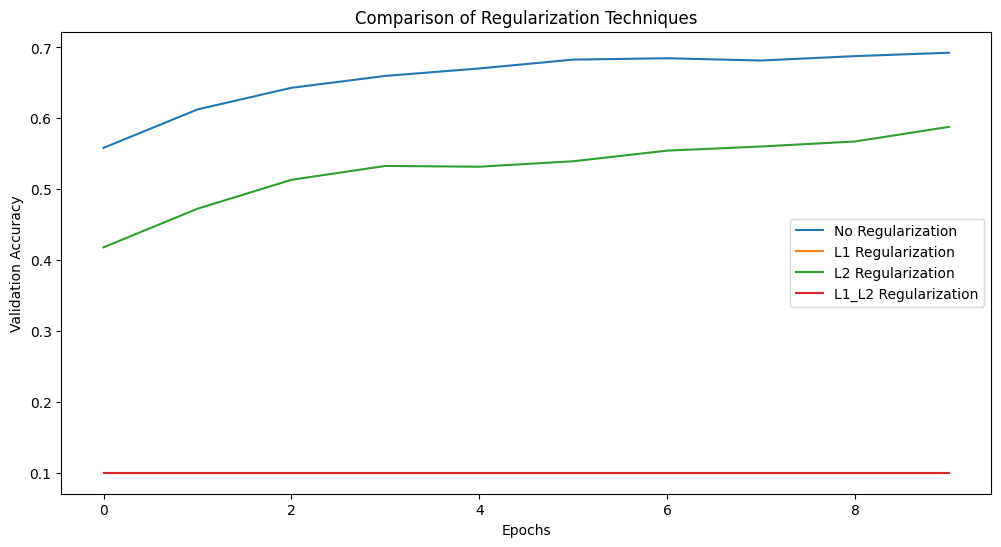

In [ ]:
# Plot training results
plt.figure(figsize=(12, 6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Comparison of Regularization Techniques')
plt.show()

L1 and L2 Regularization - README

📘 Overview

This Colab notebook demonstrates the impact of L1 (Lasso), L2 (Ridge), and combined L1_L2 regularization in a Convolutional Neural Network (CNN) using TensorFlow and Keras. The model is trained on the CIFAR-10 dataset to illustrate how regularization improves generalization.

🧪 Objective

To understand how L1, L2, and L1_L2 regularization techniques help in:

Reducing overfitting

Encouraging sparsity (L1)

Penalizing large weights (L2)

Balancing sparsity and stability (L1_L2)

🛠️ Implementation Details

Dataset: CIFAR-10

Model Architecture: CNN with 2 Conv2D layers, MaxPooling, Flatten, Dense layers

Regularization Strategies:

No Regularization

L1: regularizers.l1(0.01)

L2: regularizers.l2(0.01)

L1_L2: regularizers.l1_l2(l1=0.01, l2=0.01)

Training Setup:

Epochs: 10

Batch Size: 64

Optimizer: Adam

Loss: Sparse Categorical Crossentropy

📈 Results

Each model's validation accuracy over 10 epochs is plotted to show how each regularization technique affects performance:

No Regularization: High training accuracy, but susceptible to overfitting.

L1 Regularization: Promotes sparsity in weights, helps reduce overfitting.

L2 Regularization: Reduces the magnitude of weights, stabilizes learning.

L1_L2 Regularization: Combines benefits of L1 and L2; good balance of sparsity and control.

🧠 Insights

L1 regularization is ideal for feature selection and sparse models.

L2 is better suited for scenarios where we want to avoid very large weights.

L1_L2 is used when both weight sparsity and regularized training are desired.

Regularization is a critical tool to enhance generalization, especially with limited data or complex models.

📎 Files

l1_l2_regularization.ipynb: Main Colab notebook for L1/L2 experiment.

README.md: This documentation file.

✅ Next Steps

Try out:

Varying regularization strengths (e.g., 0.001, 0.005, 0.02)

Applying regularization only on certain layers

Combining with other techniques like dropout or data augmentation

📚 References

TensorFlow Docs: https://www.tensorflow.org/api_docs/python/tf/keras/regularizers

Aurelien Geron’s Notebooks: https://github.com/ageron/handson-ml3

